# 較正込み市場クオートGreeksのDML

単一曲線＋cash digital（K100、sigma20%、payout1）の合成比較。
Q/Theta座標とrisk metricを区別し、解析教師・5 NN方式・2低次元回帰を比較します。
このnotebookは保存JSON/NPZの表示と配列集計だけを行います。学習・価格付け・ネットアクセスは実行しません。
監査にはbuild_reference.py --checkを使ってください。smoke表示は主実験の性能結論ではありません。


In [1]:
import importlib.util
import json
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

# Headless parent processes may export MPLBACKEND=Agg. Select notebook output
# explicitly so plt.show() always writes the artifact's inline PNGs.
get_ipython().run_line_magic("matplotlib", "inline")

# An evidence-store resolver may set these paths before this display cell.
# No machine-specific artifact path is saved into the notebook.
artifact_dir = Path(os.environ.get("JOHNHULL_QUOTE_DML_ARTIFACT_DIR", "."))
record = json.loads((artifact_dir / "reference.json").read_text())
with np.load(artifact_dir / "reference.npz", allow_pickle=False) as source:
    arrays = {key: source[key] for key in source.files}
replay_file = Path(os.environ.get("JOHNHULL_QUOTE_DML_REPLAY_PATH", "replay.py"))
spec = importlib.util.spec_from_file_location("quote_dml_artifact_replay", replay_file)
replay = importlib.util.module_from_spec(spec)
spec.loader.exec_module(replay)
summary = replay.metrics(arrays, record["protocol"])
plt.rcParams.update({"figure.dpi": 120, "font.size": 9})
methods = ["q_price", "theta_price", "theta_dml", "theta_quote_metric", "q_dml", "ridge_price", "ridge_dml"]
names = {"q_price": "Q price", "theta_price": "Theta price", "theta_dml": "Theta DML",
         "theta_quote_metric": "Theta quote\nmetric", "q_dml": "Q DML",
         "ridge_price": "Reduced price", "ridge_dml": "Reduced DML"}
models = summary["models"]
sizes = sorted({model["training_size"] for model in models.values()})
seeds = record["protocol"]["training"]["seeds"]
size_colors = plt.get_cmap("tab10")(np.linspace(0, .8, max(len(sizes), 2)))
seed_markers = {seed: marker for seed, marker in zip(seeds, ["o", "s", "^"])}
def position(model):
    offset = (sizes.index(model["training_size"]) - (len(sizes)-1)/2) * .26
    if model["training_seed"] is not None:
        offset += (seeds.index(model["training_seed"]) - (len(seeds)-1)/2) * .065
    return methods.index(model["method"]) + offset
def decorate_methods(ax):
    ax.set_xticks(range(len(methods)), [names[name] for name in methods], rotation=35, ha="right")
    ax.set_xlim(-.5, len(methods)-.5)
    ax.grid(axis="y", alpha=.2)
status = "Main synthetic experiment" if record["experiment"] == "main" else "SMOKE ONLY: not a performance conclusion"
if not record.get("complete_fits", False):
    status += "; incomplete fits: comparison is not complete"
print(status)
display(Markdown("同じ市場曲線の8契約を1群として評価。CIは固定した各学習seedに条件付きで、将来seedの不確実性ではありません。"))


Main synthetic experiment


同じ市場曲線の8契約を1群として評価。CIは固定した各学習seedに条件付きで、将来seedの不確実性ではありません。

## 1. 価格と市場risk：全seedと条件付きCI

価格RMSE、train-only quote RMSで標準化した6成分Greek RMSEを表示。
H1はQ DML対Q price、H2はQ DML対Theta quote metric。
市場曲線単位のpaired bootstrapを用い、良かったseedだけを選びません。

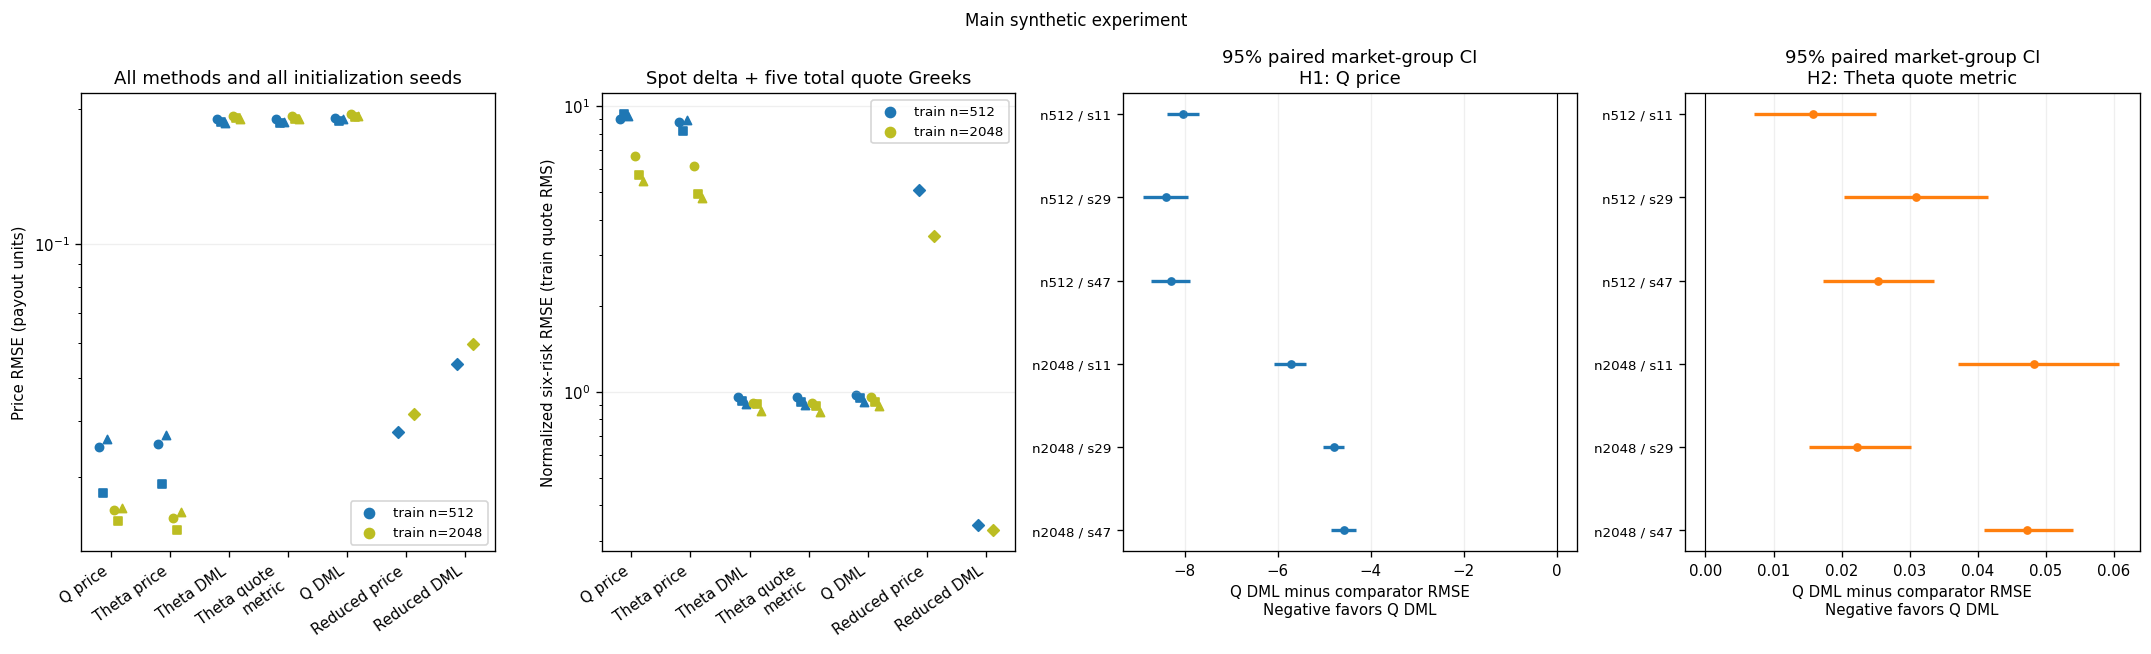

Seed markers: circle=11, square=29, triangle=47; diamond=deterministic ridge.


In [2]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5.5), gridspec_kw={"width_ratios": [1, 1, 1.1, 1.1]})
for identifier, model in models.items():
    x = position(model)
    color = size_colors[sizes.index(model["training_size"])]
    marker = seed_markers.get(model["training_seed"], "D")
    for ax, key, subkey in [(axes[0], "price", "rmse"), (axes[1], "normalized_risk", "rmse")]:
        ax.scatter(x, max(model[key][subkey], 1e-14), color=color, marker=marker, s=24)
for ax in axes[:2]:
    decorate_methods(ax)
    ax.set_yscale("log")
    for i, size in enumerate(sizes):
        ax.scatter([], [], color=size_colors[i], label=f"train n={size}")
    ax.legend(fontsize=8)
axes[0].set_ylabel("Price RMSE (payout units)")
axes[0].set_title("All methods and all initialization seeds")
axes[1].set_ylabel("Normalized six-risk RMSE (train quote RMS)")
axes[1].set_title("Spot delta + five total quote Greeks")
for ax, name in zip(axes[2:], ["H1", "H2"]):
    intervals = [item for item in summary["hypotheses"][name] if item["status"] == "computed"]
    for row, item in enumerate(intervals):
        low, high = item["ci95"]
        color = "tab:blue" if name == "H1" else "tab:orange"
        ax.hlines(row, low, high, color=color, linewidth=2)
        ax.scatter(item["difference"], row, color=color, s=18)
    ax.axvline(0, color="black", linewidth=.7)
    ax.set_yticks(range(len(intervals)),
                 [f"n{item['training_size']} / s{item['training_seed']}" for item in intervals], fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel("Q DML minus comparator RMSE\nNegative favors Q DML")
    ax.set_title(f"95% paired market-group CI\n{name}: " + ("Q price" if name == "H1" else "Theta quote metric"))
    ax.grid(axis="x", alpha=.2)
fig.suptitle(status, fontsize=10)
fig.tight_layout()
plt.show()
print("Seed markers: circle=11, square=29, triangle=47; diamond=deterministic ridge.")


## 2. 固定契約ヘッジ：残余と費用を別々に見る

中心市場で固定したcouponをショック後も保持。株式1単位と金利契約100万元本の数量を使います。
金利1bp/10bp、spot、組合せ、全35shockを区別し、入口費用は別に表示します。金利群とspot群を分けた図は事後の記述的分解で、追加の有意性検定ではありません。

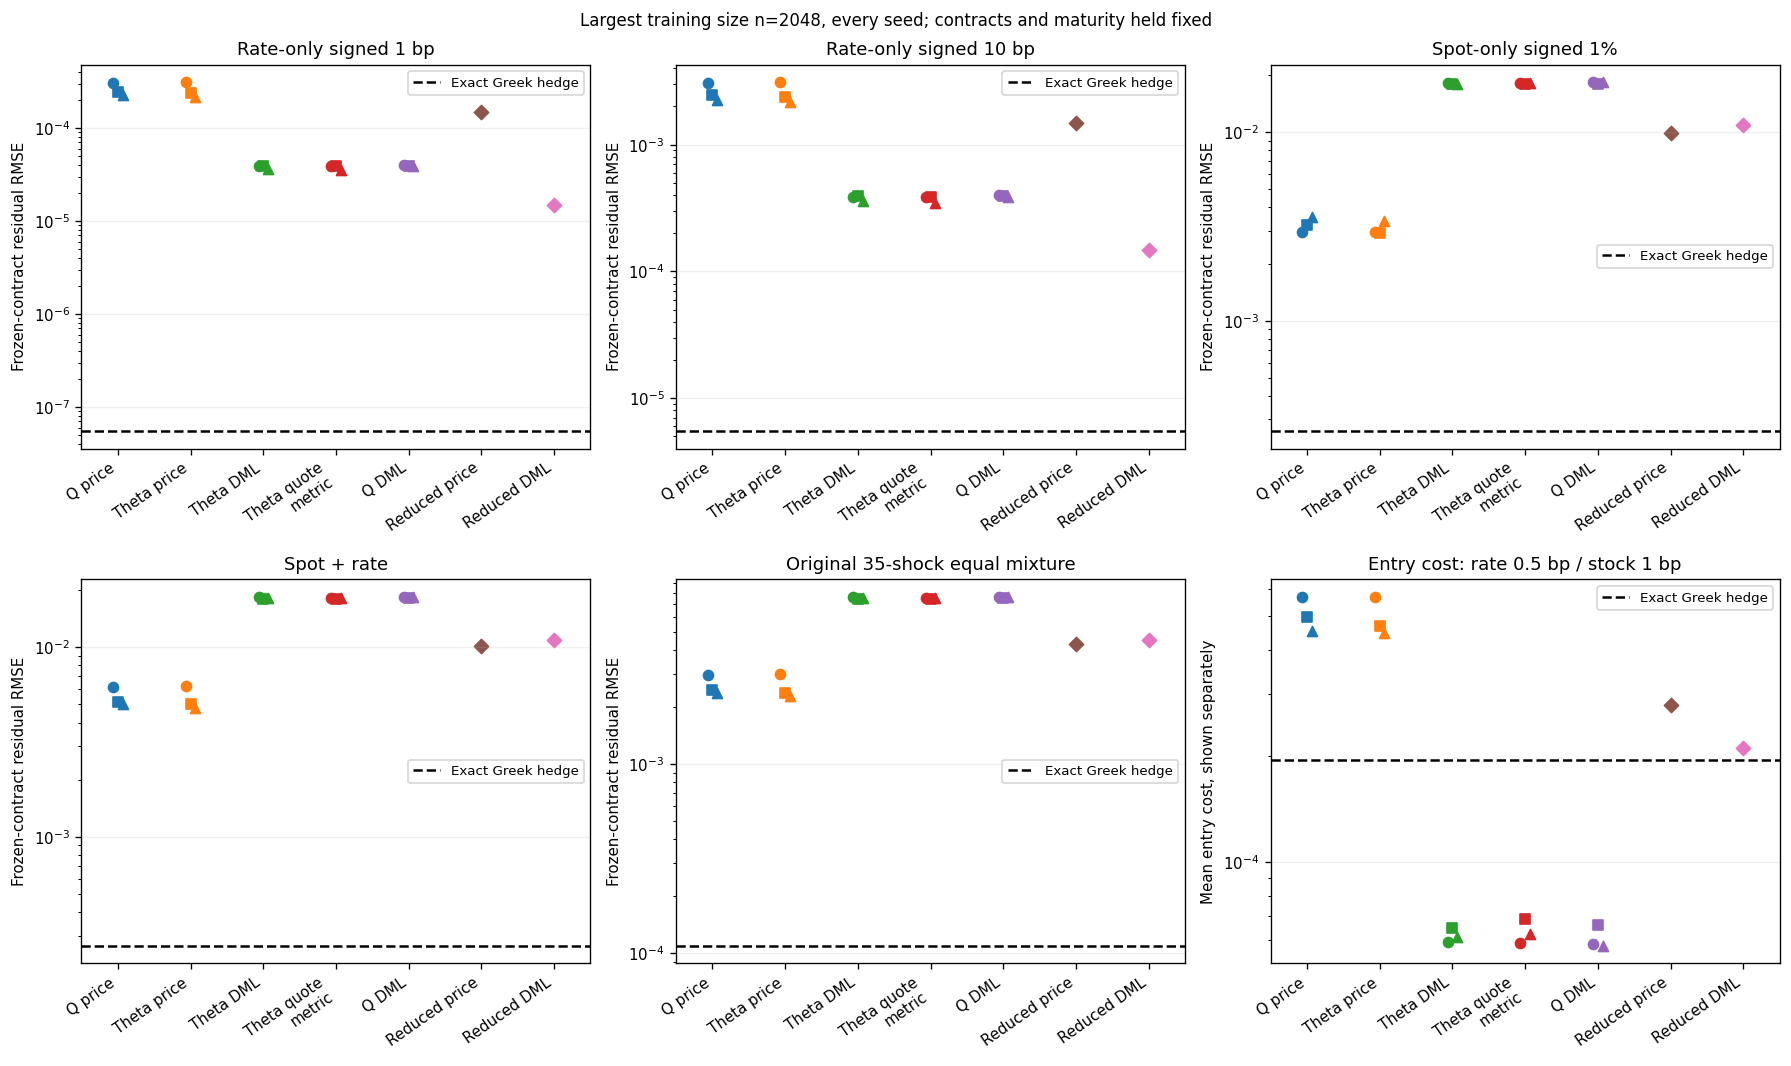

瞬間ショック再評価です。金利だけの改善とspot/複合の悪化を分けて表示します。期間損益・自己資金戦略・動的取引費用の成績ではありません。入口費用を残余へ合算して利益率にしません。

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()
largest = max(sizes)
shock_labels = np.asarray(arrays["shock_labels"]).astype(str)
groups = [
    ("Rate-only signed 1 bp", np.array([label.endswith("1bp") and not label.startswith("combined") for label in shock_labels])),
    ("Rate-only signed 10 bp", np.array([label.endswith("10bp") and not label.startswith("combined") for label in shock_labels])),
    ("Spot-only signed 1%", np.array([label.startswith("spot_") for label in shock_labels])),
    ("Spot + rate", np.array([label.startswith("combined") for label in shock_labels])),
    ("Original 35-shock equal mixture", np.ones(len(shock_labels), dtype=bool)),
]
rate_index = int(np.argmin(np.abs(arrays["cost_rate_bp"] - .5)))
stock_index = int(np.argmin(np.abs(arrays["cost_stock_bp"] - 1.)))
for identifier, model in models.items():
    if model["training_size"] != largest:
        continue
    x = methods.index(model["method"]) + (.065 * (seeds.index(model["training_seed"])-1) if model["training_seed"] is not None else 0)
    marker = seed_markers.get(model["training_seed"], "D")
    color = plt.get_cmap("tab10")(methods.index(model["method"]))
    residual = arrays[f"pred__{identifier}__residual"]
    for ax, (_, mask) in zip(axes[:5], groups):
        if mask.any():
            ax.scatter(x, max(float(np.sqrt(np.mean(residual[:, mask]**2))), 1e-14), color=color, marker=marker)
    cost = arrays[f"pred__{identifier}__cost"][:, rate_index, stock_index]
    axes[5].scatter(x, max(float(cost.mean()), 1e-14), color=color, marker=marker)
for ax, (title, mask) in zip(axes[:5], groups):
    if mask.any():
        exact_rmse = float(np.sqrt(np.mean(arrays["reference_residual"][:, mask]**2)))
        ax.axhline(max(exact_rmse, 1e-14), color="black", linestyle="--", label="Exact Greek hedge")
        ax.legend(fontsize=8)
    ax.set_title(title)
    ax.set_ylabel("Frozen-contract residual RMSE")
reference_rates = np.sum(np.abs(arrays["reference_h"][:, 1:] * np.diagonal(arrays["test_B"], axis1=1, axis2=2)[:, 1:]), axis=1) * 1e-4
reference_stock = arrays["test_x_quote"][:, 5] * np.abs(arrays["reference_h"][:, 0]) * 1e-4
reference_cost = reference_rates * arrays["cost_rate_bp"][rate_index] + reference_stock * arrays["cost_stock_bp"][stock_index]
axes[5].axhline(max(float(reference_cost.mean()), 1e-14), color="black", linestyle="--", label="Exact Greek hedge")
axes[5].legend(fontsize=8)
axes[5].set_title(f"Entry cost: rate {arrays['cost_rate_bp'][rate_index]:g} bp / stock {arrays['cost_stock_bp'][stock_index]:g} bp")
axes[5].set_ylabel("Mean entry cost, shown separately")
for ax in axes:
    decorate_methods(ax)
    ax.set_yscale("log")
fig.suptitle(f"Largest training size n={largest}, every seed; contracts and maturity held fixed", fontsize=10)
fig.tight_layout()
plt.show()
display(Markdown("瞬間ショック再評価です。金利だけの改善とspot/複合の悪化を分けて表示します。期間損益・自己資金戦略・動的取引費用の成績ではありません。入口費用を残余へ合算して利益率にしません。"))


## 3. 精度と総費用：raw kernelと安全wrapperを区別する

同じbatchの保存済み計時を使い、C(N_calls)=教師・fit/export・測定済みload費用＋N_calls×全batch費用を描きます。query件数には切り上げたbatch回数を使い、部分batchを割引しません。
rawでは入力・特徴の準備費用を含まない場合があります。safeとexactは同じmarket cache条件です。
safe精度は保存済みsafe出力から計算します。計時やsafe出力がなければ未計測と明示します。
このCPU環境での観測であり、速度向上や回収可能性を前提にしません。

Selected comparators: Exact / prepared; Q price / raw; Theta price / raw; Theta DML / raw; Theta quote metric / raw; Q DML / raw; Reduced price / raw; Reduced DML / raw; Exact / calibrated; Q price / safe; Theta price / safe; Theta DML / safe; Theta quote metric / safe; Q DML / safe; Reduced price / safe; Reduced DML / safe
C(N_calls) counts full batches. Query budgets require ceil(N_queries / batch); no fractional call is credited.
Offline includes measured warm-cache whole research bundle loading and one model decode. Not cold IO or a minimal deployment.
Largest n=2048, initialization seed=11 or deterministic ridge; remaining raw timings are retained in JSON.
Raw and Exact / prepared assume inputs supplied; safe and Exact / calibrated share market cache. Shading: median to p95 components, not a CI or total-cost quantile.


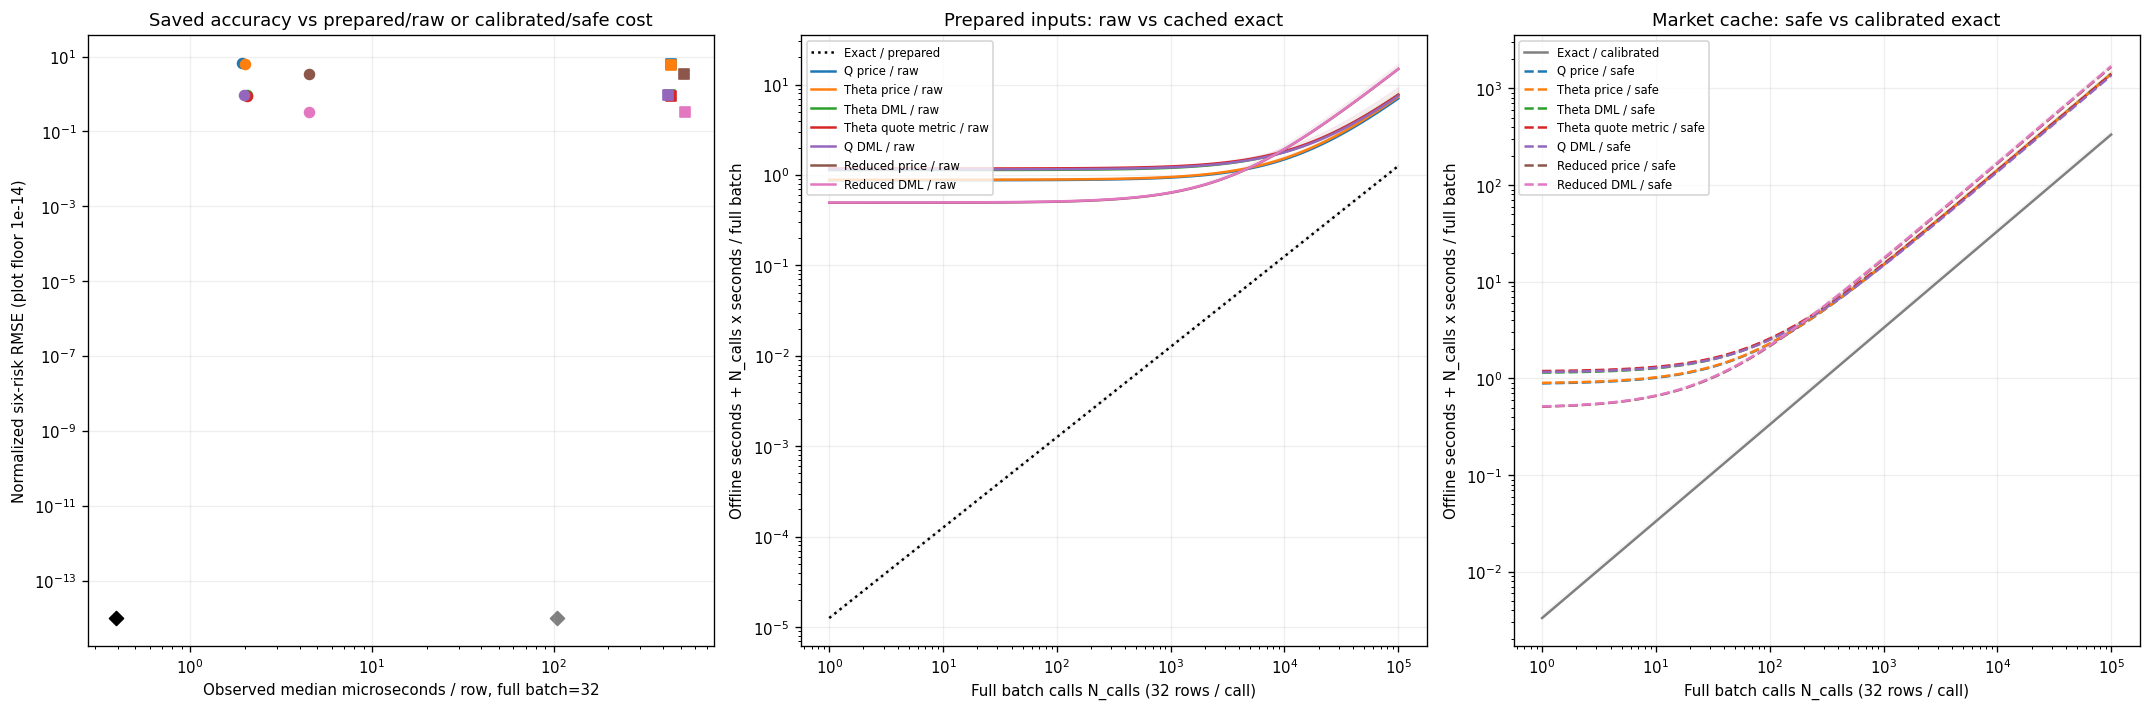

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
measurements = record.get("benchmark", {}).get("measurements", [])
timed = [item for item in measurements if item["operation"] == "price_risk"]
fits = {item["id"]: item for item in record["fits"]}
selected = []
if timed:
    batches = {int(item["batch_size"]) for item in timed}
    batch = 32 if 32 in batches else max(batches)
    for item in timed:
        if int(item["batch_size"]) != batch:
            continue
        source, identifier = item["source"], item["model_id"]
        if source == "exact_cached":
            pass
        elif source == "exact" or (source == "e2e" and identifier == "exact"):
            if item.get("cache", "market") != "market":
                continue
        elif source in ("raw", "safe") and identifier in models:
            model = models[identifier]
            if model["training_size"] != max(sizes) or model["training_seed"] not in (None, seeds[0]):
                continue
            if source == "safe" and item.get("cache", "market") != "market":
                continue
        else:
            continue
        selected.append(item)
if not selected:
    for ax in axes:
        ax.text(.5, .5, "Not measured\nTiming has not been recorded", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
    print("Not measured (未計測): cost/performance comparison is incomplete")
else:
    call_counts = np.unique(np.ceil(np.logspace(0, 5, 90)).astype(int))
    safe_missing, selected_labels = [], []
    loading = record.get("loading", {})
    bundle = loading.get("full_npz")
    for item in selected:
        source, identifier = item["source"], item["model_id"]
        batch_time = float(item["median_s"])
        p95_batch_time = float(item["p95_s"])
        exact = source in ("exact", "exact_cached") or identifier == "exact"
        if exact:
            error, offline, p95_offline = 0., 0., 0.
            label = "Exact / prepared" if source == "exact_cached" else "Exact / calibrated"
            color = "black" if source == "exact_cached" else "gray"
        else:
            model = models[identifier]
            offline = float(fits[identifier]["offline_s"])
            p95_offline = offline
            decoded = loading.get("model_decode", {}).get(identifier)
            if bundle is not None and decoded is not None:
                offline += float(bundle["median_s"]) + float(decoded["median_s"])
                p95_offline += float(bundle["p95_s"]) + float(decoded["p95_s"])
            label = names[model["method"]].replace("\n", " ") + " / " + source
            color = plt.get_cmap("tab10")(methods.index(model["method"]))
            if source == "safe":
                prefix = f"safe__{identifier}__"
                if prefix + "safe_g_quote" not in arrays:
                    safe_missing.append(identifier)
                    error = None
                else:
                    scaled = (arrays[prefix + "safe_g_quote"] - arrays["test_g_quote"]) / np.asarray(model["risk_scale"])
                    error = float(np.sqrt(np.mean(scaled**2))) if np.isfinite(scaled).all() else None
                    if error is None:
                        safe_missing.append(identifier)
            else:
                error = model["normalized_risk"]["rmse"]
        selected_labels.append(label)
        if error is not None:
            axes[0].scatter(batch_time/batch*1e6, max(error, 1e-14), color=color,
                            marker="s" if source == "safe" else ("D" if exact else "o"), s=35)
        linestyle = "--" if source == "safe" else (":" if source == "exact_cached" else "-")
        cost_ax = axes[1] if source in ("raw", "exact_cached") else axes[2]
        cost_ax.plot(call_counts, offline + batch_time*call_counts, color=color,
                     linestyle=linestyle, label=label)
        cost_ax.fill_between(call_counts, offline + batch_time*call_counts,
                             p95_offline + p95_batch_time*call_counts, color=color, alpha=.04)
    axes[0].set_xscale("log")
    axes[0].set_yscale("log")
    axes[0].set_xlabel(f"Observed median microseconds / row, full batch={batch}")
    axes[0].set_ylabel("Normalized six-risk RMSE (plot floor 1e-14)")
    axes[0].set_title("Saved accuracy vs prepared/raw or calibrated/safe cost")
    for ax, title in zip(axes[1:], ["Prepared inputs: raw vs cached exact", "Market cache: safe vs calibrated exact"]):
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel(f"Full batch calls N_calls ({batch} rows / call)")
        ax.set_ylabel("Offline seconds + N_calls x seconds / full batch")
        ax.set_title(title)
        ax.legend(fontsize=7, loc="upper left")
    for ax in axes:
        ax.grid(alpha=.2)
    print("Selected comparators: " + "; ".join(selected_labels))
    print("C(N_calls) counts full batches. Query budgets require ceil(N_queries / batch); no fractional call is credited.")
    if bundle is None:
        print("Bundle loading not measured: curves show training-only cost, not complete deployment.")
    else:
        print("Offline includes measured warm-cache whole research bundle loading and one model decode. Not cold IO or a minimal deployment.")
    if safe_missing:
        print("safe accuracy not recorded: " + ", ".join(safe_missing))
    print(f"Largest n={max(sizes)}, initialization seed={seeds[0]} or deterministic ridge; remaining raw timings are retained in JSON.")
    print("Raw and Exact / prepared assume inputs supplied; safe and Exact / calibrated share market cache. Shading: median to p95 components, not a CI or total-cost quantile.")
fig.tight_layout()
plt.show()


## 制限と次の判断

本実験は決定論的単一曲線のdigitalです。MC学習、動的ヘッジ、実市場データ、多曲線、制約付き較正の結果ではありません。
研究完了とNNの採用判断を分け、保存配列・契約・費用の監査を通した後で結論を記録します。